# Optimize tensorflow pipeline performance with prefetch and caching

> Here we measure the performance of a tf pipeline after using prefetch and cache

In [1]:
import tensorflow as tf
import time

In [2]:
tf.__version__

'2.6.0'

## Prefetch
- Here we create a class FileDataset to meature the performance of tf pipeline after using prefetch and cache
- Here reading no file just assuming some file/dummy file

In [4]:
# This creates some dummy file, just a delay like reading file

class FileDataset(tf.data.Dataset):
    
    def read_file_in_batches(num_samples):  # num_samples wants to read in 1 batch
        # Opening the file
        time.sleep(0.03)  # this is delay time for open file

        for sample_idx in range(num_samples):
            # Reading data (line, record) from the file
            time.sleep(0.015) # this is delay time set to show like its reading line by line, each line of 0.015 sec
            # Returning the sample_idx, in real life we read each line and returning that line
            # yield is a python generator
            yield (sample_idx,)

            #Whenever we call "FileDataset" class, then this _new_ function will be executed 1st
    def __new__(cls, num_samples=3):
        return tf.data.Dataset.from_generator(
            cls.read_file_in_batches,
            # output_signature is what "read_file_in_batches" funct is going to return. Here its sample_idx of dtype int64
            output_signature = tf.TensorSpec(shape = (1,), dtype = tf.int64),
            args=(num_samples,)
        )

In [6]:
def benchmark(dataset, num_epochs=2):
    for epoch_num in range(num_epochs):
        for sample in dataset:  # each epoch travels through all the rcecords in dataset, each record process of 0.01 sec
            # Performing a training step
            time.sleep(0.01)

#### In below diagram ,Function - FileDataset is read-CPU option which is of orange color AND benchmark is train-GPU of yellow color 


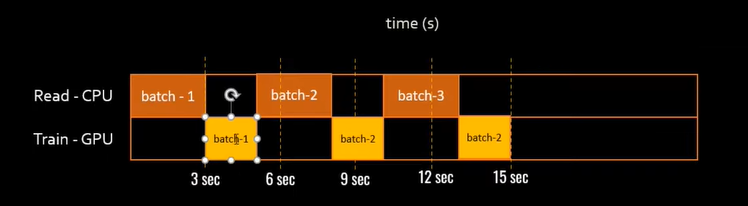

In [10]:
%%timeit
benchmark(FileDataset())
# HERE WE ARE PASSING CLASS =>  FileDataset() , which is sample file inside Benchmark function

367 ms ± 16.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
%%timeit
benchmark(FileDataset().prefetch(1))
# Same one adding prefetch(1) --> prefetch 1 sample

333 ms ± 15.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
%%timeit
benchmark(FileDataset().prefetch(tf.data.AUTOTUNE))
# Same one adding prefetch((tf.data.AUTOTUNE))

313 ms ± 16.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


#### As you can notice above, using prefetch improves the performance from 367 ms to 333  and 313  ms

## Cache

In [15]:
dataset = tf.data.Dataset.range(5)
dataset = dataset.map(lambda x: x**2)
for i in dataset:
    print(i.numpy())

0
1
4
9
16


In [16]:
dataset = dataset.cache("mycache.txt")
# The first time reading through the data will generate the data using
# `range` and `map`.
list(dataset.as_numpy_iterator())

[0, 1, 4, 9, 16]

In [17]:
# Subsequent iterations read from the cache.
list(dataset.as_numpy_iterator())

[0, 1, 4, 9, 16]

In [18]:
def mapped_function(s):
    # Do some hard pre-processing  , here just adds delay like its processing data
    tf.py_function(lambda: time.sleep(0.03), [], ())
    return s

In [19]:
%%timeit -r1 -n1
benchmark(FileDataset().map(mapped_function), 5)
# here "mapped_function" function called 5 times (epoch=5)

1.74 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [21]:
%%timeit -r1 -n1
benchmark(FileDataset().map(mapped_function).cache(), 5)
# here "mapped_function" function called 5 times (epoch=5), but only 1 time it does all process, and remaining epoch its uses data from cache, its not going to read and all


588 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


#### As you can notice above, using cache improves the performance from 1.74 s to 588  ms

> **Further reading https://www.tensorflow.org/guide/data_performance#caching**